In [1]:
import numpy as np
import simpful
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [2]:
FS = simpful.FuzzySystem(show_banner=False)

## Entry variables

### Squares advanced by pawns

In [3]:
not_advanced = simpful.FuzzySet(points=[[0, 1.0], [4, 0.0]], term="not_advanced")
advanced = simpful.TrapezoidFuzzySet(0, 4, 8, 12, term="advanced")
over_extended = simpful.FuzzySet(points=[[8, 0.0], [12, 1.0]], term="over_extended")


FS.add_linguistic_variable(
    "Pawn_Position",
    simpful.LinguisticVariable(
        [not_advanced, advanced, over_extended],
        universe_of_discourse=[0, 12]
    )
)

### Number of undefended pawns (by other pawns)

In [4]:
low = simpful.FuzzySet(points=[[0, 1.0], [2, 1.0], [7, 0.0]], term="low")
high = simpful.FuzzySet(points=[[2, 0.0], [8, 1.0]], term="high")

FS.add_linguistic_variable(
    "Undefended_Pawns",
    simpful.LinguisticVariable(
        [low, high],
        universe_of_discourse=[0,8]
    )
)

### Number of pawn islands

In [5]:
few = simpful.FuzzySet(points=[[1, 1.0], [4, 0.0]], term="few")
many = simpful.FuzzySet(points=[[1, 0.0], [4, 1.0]], term="many")

FS.add_linguistic_variable(
    "Pawn_Islands",
    simpful.LinguisticVariable(
        [few, many],
        universe_of_discourse=[0,4]
    )
)

## Output variable: Pawn structure quality

In [6]:
desired_universe = [-10, 10]
terms = ["very_bad", "bad", "neutral", "good", "very_good"]
n_terms = len(terms)
centers = np.linspace(desired_universe[0], desired_universe[1], n_terms)
width = centers[1] - centers[0]
universe = [desired_universe[0] - width, desired_universe[1] + width]

fuzzy_sets = []

for i in range(n_terms):
    a = centers[i] - width
    b = centers[i]
    c = centers[i] + width

    fuzzy_sets.append(simpful.TriangleFuzzySet(a, b, c, term=terms[i]))

FS.add_linguistic_variable(
    "Pawn_Structure",
    simpful.LinguisticVariable(
        fuzzy_sets,
        universe_of_discourse=universe
    )
)

## Rule system

In [7]:
rules = [
    # Low pawn-undefended pawns
    "IF (Pawn_Position IS over_extended) AND (Undefended_Pawns IS low) THEN (Pawn_Structure IS very_good)",
    "IF (Pawn_Position IS advanced) AND (Undefended_Pawns IS low) THEN (Pawn_Structure IS good)",
    "IF (Pawn_Position IS not_advanced) AND (Undefended_Pawns IS low) THEN (Pawn_Structure IS neutral)",

    # High pawn-undefended pawns
    "IF (Pawn_Position IS over_extended) AND (Undefended_Pawns IS high) AND (Pawn_Islands IS many) THEN (Pawn_Structure IS very_bad)",
    "IF (Pawn_Position IS over_extended) AND (Undefended_Pawns IS high) AND (Pawn_Islands IS few) THEN (Pawn_Structure IS bad)",
    "IF (Pawn_Position IS advanced) AND (Undefended_Pawns IS high) AND (Pawn_Islands IS many) THEN (Pawn_Structure IS bad)",
    "IF (Pawn_Position IS advanced) AND (Undefended_Pawns IS high) AND (Pawn_Islands IS few) THEN (Pawn_Structure IS neutral)",
    "IF (Pawn_Position IS not_advanced) AND (Undefended_Pawns IS high) AND (Pawn_Islands IS many) THEN (Pawn_Structure IS bad)",
    "IF (Pawn_Position IS not_advanced) AND (Undefended_Pawns IS high) AND (Pawn_Islands IS few) THEN (Pawn_Structure IS neutral)",
]

FS._rules = []
FS.add_rules(rules)

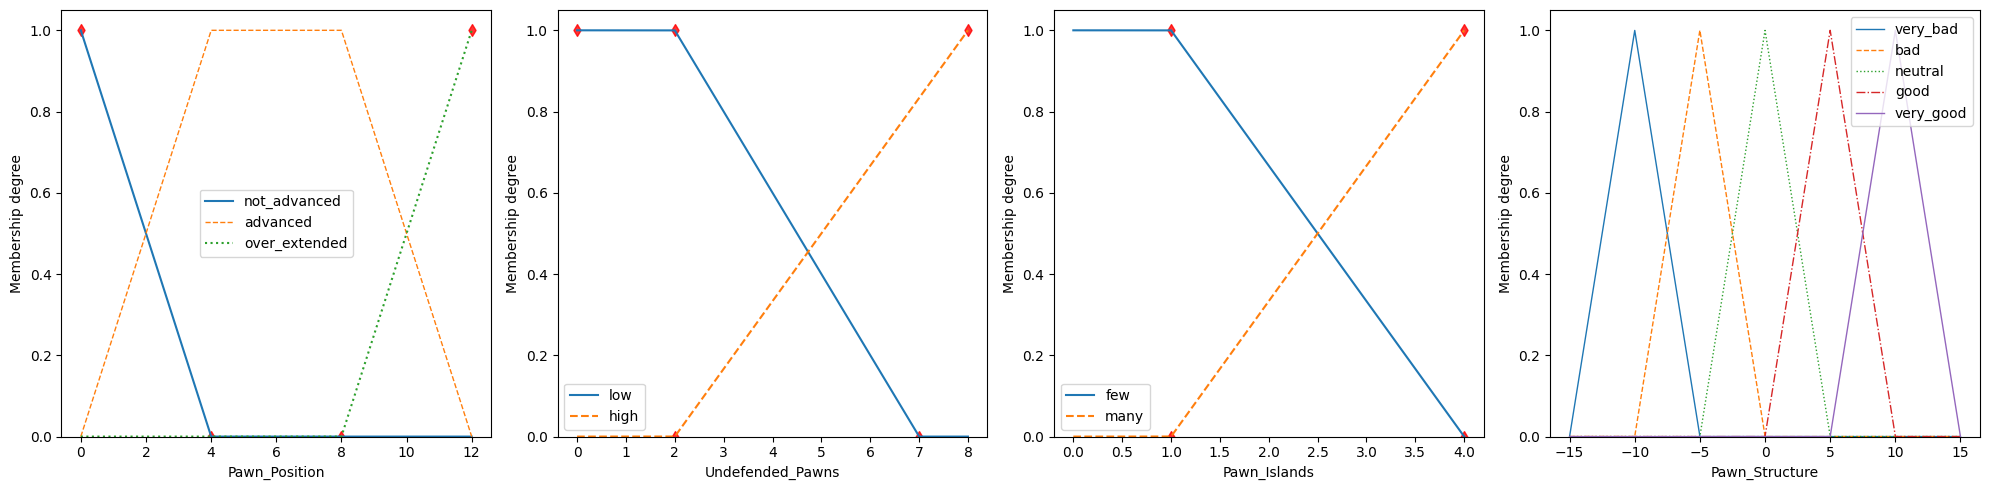

In [8]:
FS.produce_figure()

## Response surface

### Calculations

In [9]:
# Define grid resolution (higher = smoother surface, but slower to compute)
resolution = 20

# Evaluate fuzzy system on a 2D mesh
# Create the 2D meshgrid
x_position = np.linspace(0, 13, resolution)
y_undefended = np.linspace(0, 9, resolution)
X, Y = np.meshgrid(x_position, y_undefended)
Z = np.zeros_like(X)

FS.set_variable("Pawn_Islands", 2)

# Evaluate the fuzzy system at each point on the mesh
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        FS.set_variable("Pawn_Position", float(X[i, j]))
        FS.set_variable("Undefended_Pawns", float(Y[i, j]))
        
        # Run inference
        result = FS.inference()
        Z[i, j] = result["Pawn_Structure"]

### Configure and show plot

In [10]:
# Create the interactive 3D plot with Plotly
fig = go.Figure(data=[go.Surface(
    z=Z, 
    x=X, 
    y=Y, 
    colorscale='Viridis',
    showscale=False, # Removes the colorbar on the side
    hovertemplate='Advanced (X): %{x:.2f}<br>Undefended (Y): %{y:.2f}<br>Structure Score (Z): %{z:.2f}<extra></extra>'
)])

# Configure layout, titles, camera, and proportions
fig.update_layout(
    title='Central Control Response Surface',
    scene=dict(
        xaxis_title='Advanced Pawns',
        yaxis_title='Undefended Pawns',
        zaxis_title='Pawn Structure Score',
        aspectmode='cube', # Forces the visual base of the plot to be square
        camera=dict(
            eye=dict(x=1.5, y=-1.5, z=1.2)
        )
    ),
    width=600, 
    height=500,
    margin=dict(l=10, r=0, b=30, t=40) 
)

fig.show()

## Export FIS to lookup table

### Calculate table

In [11]:
# Generate grid
x = np.arange(0, 11)   # advanced pawns
y = np.arange(0, 9)    # undefended pawns
z = np.arange(0, 5)    # pawn islands

structure_lut = np.zeros((len(x), len(y), len(z)))

# Fill table by calculating output for every possible combination
print("Calculating lookup table...")
for i, adv in enumerate(x):
    for j, undef in enumerate(y):
        for k, isl_count in enumerate(z):
            FS.set_variable("Pawn_Position", adv)
            FS.set_variable("Undefended_Pawns", undef)
            FS.set_variable("Pawn_Islands", isl_count)

            result = FS.inference()["Pawn_Structure"]
            structure_lut[i, j, k] = result

print(f"Lookup table calculated. Shape: {structure_lut.shape}.")

Calculating lookup table...
Lookup table calculated. Shape: (11, 9, 5).


### Save in file

In [12]:
import os

# Make sure the directory exists
os.makedirs("../data/luts", exist_ok=True)

file_path = "../data/luts/structure_lut.npy"
np.save(file_path, structure_lut)

print(f"Successfully saved lookup table as {file_path}.")

Successfully saved lookup table as ../data/luts/structure_lut.npy.
